In [1]:
'''
🚀 PROJETO 9 — 
🧠 Tema do projeto
Análise de comportamento de clientes (Customer Analytics)


🎯 Objetivo

Você vai responder:

Quem são os melhores clientes?
Onde está o dinheiro?
Quem está sendo subaproveitado?
🧱 O que você VAI construir

Um mini pipeline com:

dados → transformação → métricas → segmentação → insights
📦 Dataset

👉 Use o mesmo (Superstore / Kaggle)

Isso é proposital:

menos esforço técnico → mais foco analítico
🧭 ETAPA 1 — Base de dados

Crie tabelas claras:

df_orders
df_customers

👉 Depois:

df_final (joinado)
🧭 ETAPA 2 — Criação de métricas

Você NÃO vai só agregar.

Você vai criar métricas por cliente.

Perguntas que guiam:

quanto cada cliente gasta?
quantas compras faz?
qual ticket médio?

⚠️ Você deve chegar em algo tipo:
Customer Name | Total_Revenue | Total_Orders | Avg_Ticket

🧭 ETAPA 3 — Feature Engineering (o diferencial)

Agora você começa a pensar como analista de verdade.

Crie pelo menos 2 dessas:

- ticket médio
- frequência de compra
- receita total por cliente
- ranking de clientes

🧭 ETAPA 4 — Segmentação 
Você vai dividir clientes.

Sem fórmula pronta — pense:

quem são:
- clientes top?
- clientes médios?
- clientes fracos?

💡 Dica:

Você pode usar:

quantis (top 20%, etc)

🧭 ETAPA 5 — Análise

Agora você responde perguntas reais:

Top clientes representam quanto da receita?
Existe concentração?
Muitos clientes geram pouco valor?
🧭 ETAPA 6 — Visualização (agora com propósito)

Aqui muda o jogo:

Você vai escolher gráficos para responder perguntas.

Exemplos:

- distribuição de receita por cliente → (histograma)
- top clientes → (bar chart)
- concentração → (curva acumulada)
🧠 ETAPA 7 — INSIGHTS (obrigatório)

Agora você escreve (isso é o que te contrata):

Exemplo do tipo esperado:

- 20% dos clientes geram ~80% da receita
- há grande concentração em poucos clientes
- maioria dos clientes tem baixo ticket médio
⚠️ REGRAS DO PROJETO

Não faça isso:

❌ só código
❌ só gráfico
❌ só tabela

Faça isso:

✔ código claro
✔ nomes bons
✔ métricas úteis
✔ insights escritos
🧠 O QUE ESSE PROJETO DESENVOLVE

Você vai treinar:

✔ pensamento de negócio
✔ análise de clientes (muito usado)
✔ feature engineering
✔ storytelling com dados
🏁 CRITÉRIO DE APROVAÇÃO

1. Clareza do código
2. Qualidade das métricas
3. Nível dos insights
4. Estrutura de análise
🔥 Desafio bônus (se quiser subir nível)

Tente responder:

"se você fosse a empresa, o que faria com essa análise?
'''

'\n🚀 PROJETO 9 — \n🧠 Tema do projeto\nAnálise de comportamento de clientes (Customer Analytics)\n\n\n🎯 Objetivo\n\nVocê vai responder:\n\nQuem são os melhores clientes?\nOnde está o dinheiro?\nQuem está sendo subaproveitado?\n🧱 O que você VAI construir\n\nUm mini pipeline com:\n\ndados → transformação → métricas → segmentação → insights\n📦 Dataset\n\n👉 Use o mesmo (Superstore / Kaggle)\n\nIsso é proposital:\n\nmenos esforço técnico → mais foco analítico\n🧭 ETAPA 1 — Base de dados\n\nCrie tabelas claras:\n\ndf_orders\ndf_customers\n\n👉 Depois:\n\ndf_final (joinado)\n🧭 ETAPA 2 — Criação de métricas\n\nVocê NÃO vai só agregar.\n\nVocê vai criar métricas por cliente.\n\nPerguntas que guiam:\n\nquanto cada cliente gasta?\nquantas compras faz?\nqual ticket médio?\n\n⚠️ Você deve chegar em algo tipo:\nCustomer Name | Total_Revenue | Total_Orders | Avg_Ticket\n\n🧭 ETAPA 3 — Feature Engineering (o diferencial)\n\nAgora você começa a pensar como analista de verdade.\n\nCrie pelo menos 2 dessas:\

In [2]:
!pip install kagglehub


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Hyego Jarllys\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [3]:
import kagglehub

# Download DataSet do Kaggle
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Hyego Jarllys\.cache\kagglehub\datasets\vivek468\superstore-dataset-final\versions\1


In [4]:
import os

# Listar arquivos no diretório do dataset
arquivo=os.listdir(path)
print(arquivo)

['Sample - Superstore.csv']


In [5]:
import pandas as pd
#ingestão do dataset- leitura do arquivo CSV
data= r'C:\Users\Hyego Jarllys\.cache\kagglehub\datasets\vivek468\superstore-dataset-final\versions\1\Sample - Superstore.csv'
df=pd.read_csv(data, encoding = 'Windows-1252')
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [6]:
#remoção de duplicatas e verificação dos tipos de dados
df=df.drop_duplicates()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [7]:
#transformação de colunas de data para o formato datetime
df['Ship Date']=pd.to_datetime(df['Ship Date'])
df['Order Date']=pd.to_datetime(df['Order Date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [8]:
# separar em tabelas diferentes (Normalização)
df_customers = df[['Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region']]
df_orders = df[['Order ID', 'Order Date', 'Ship Date', 'Ship Mode','Customer ID', 'Product ID','Sales', 'Quantity', 'Discount', 'Profit']]
df_products = df[['Product ID', 'Category', 'Sub-Category', 'Product Name']]


In [ ]:
#análise estatística dos melhores clientes
df_customers.describe()


,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
mean,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,229.858001,3.789574,0.156203,28.656896
min,2014-01-03 00:00:00,2014-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2015-05-23 00:00:00,2015-05-27 00:00:00,17.280000,2.000000,0.000000,1.728750
50%,2016-06-26 00:00:00,2016-06-29 00:00:00,54.490000,3.000000,0.200000,8.666500
75%,2017-05-14 00:00:00,2017-05-18 00:00:00,209.940000,5.000000,0.200000,29.364000
max,2017-12-30 00:00:00,2018-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,NaN,NaN,623.245101,2.225110,0.206452,234.260108


In [10]:
#agora vamos criar um banco de dados SQL e inserir as tabelas criadas
import sqlite3

conn= sqlite3.connect('superstore.db')

df_customers.to_sql('customers', conn,  if_exists= 'replace', index= False)
df_orders.to_sql('orders', conn,  if_exists= 'replace', index= False)
df_products.to_sql('products', conn,  if_exists='replace', index= False)



9994

In [55]:
#agrupando a categoria cliente para criar métricas por cliente
query='''
create view if not exists customer_agg as 
select   c."Customer Name",
         c."Customer ID",
         sum(o.Sales) as Total_Sales,
         count(distinct o."Order ID") as Total_Orders,
         sum(o.Sales) as Total_Revenue,
         sum(o.Profit) as total_Profit,
         sum(o.Sales)/count(distinct o."Order ID") as Avg_Ticket
from customers c
inner join orders o
on o."Customer ID" = c."Customer ID"
group by c."Customer Name", c."Customer ID"

'''
conn.execute(query)

In [ ]:
#gravando a variável com a consulta SQL para análise estatística dos clientes
query='''
select *
from customer_agg
'''
customers_agg= pd.read_sql(query, conn)
customers_agg.describe()


,Total_Sales,Total_Orders,Total_Revenue,total_Profit,Avg_Ticket
count,793.000000,793.000000,793.000000,793.000000,793.000000
mean,45290.520384,6.316520,45290.520384,5735.619094,6282.595070
std,56374.498368,2.550885,56374.498368,14432.535683,6941.553194
min,5.304000,1.000000,5.304000,-59637.505500,4.833000
25%,9785.106800,5.000000,9785.106800,259.126000,2005.587500
50%,27018.002000,6.000000,27018.002000,2584.113400,4285.648000
75%,57484.710000,8.000000,57484.710000,7328.606000,7816.804000
max,411081.641000,17.000000,411081.641000,126663.061800,75129.150000


In [ ]:
#agora vamos criar a segmentação de clientes com base na receita total
query = '''
create view customer_segment as 
select *,
       case 
           when Total_Revenue >= 57484 then 'Gold'
           when Total_Revenue >= 27018 then 'Silver'
           else 'Bronze'
       end as Segment
from customer_agg
'''
conn.execute(query)

In [ ]:
# Criando a view customer_segment com a segmentação baseada na receita total
query='''
select *
from customer_segment
'''
customer_segment = pd.read_sql(query, conn)
customer_segment.head(3)

,Customer Name,Customer ID,Total_Sales,Total_Orders,Total_Revenue,total_Profit,Avg_Ticket,Segment
0,Aaron Bergman,AB-10015,5316.936,3,5316.936,776.0790,1772.312000,Bronze
1,Aaron Hawkins,AH-10030,19191.700,7,19191.700,4017.3672,2741.671429,Bronze
2,Aaron Smayling,AS-10045,30506.920,7,30506.920,-2535.7460,4358.131429,Silver


In [111]:
#visão de Pareto para entender a concentração de receita por segmento
query_pareto = '''
select 
    Segment,
    count(*) as Qtd_Clientes,
    round(sum(Total_Revenue), 2) AS Faturamento_Total,
    round(cast(count(*) as float) / (select count(*) from customer_segment) * 100, 2) as Perc_Clientes,
    round(sum(Total_Revenue) / (select sum(Total_Revenue) from customer_segment) * 100, 2) as Perc_Faturamento
from customer_segment
group by Segment
order by Faturamento_Total desc
'''

df_pareto = pd.read_sql(query_pareto, conn)
print(df_pareto)

  Segment  Qtd_Clientes  Faturamento_Total  Perc_Clientes  Perc_Faturamento
0    Gold           199        23580434.33          25.09             65.66
1  Silver           198         8023378.39          24.97             22.34
2  Bronze           396         4311569.95          49.94             12.00


In [ ]:
# Análise do ticket médio, lucro total e margem de lucro por segmento
query_financeiro = '''
select 
    Segment,
    round(avg(Avg_Ticket), 2) as Ticket_Medio_Real,
    round(sum(total_Profit), 2) as Lucro_Total,
    round((sum(total_Profit) / sum(Total_Revenue)) * 100, 2) as Margem_Lucro_Perc
from customer_segment
group by Segment
order by Ticket_Medio_Real desc
'''

df_financeiro = pd.read_sql(query_financeiro, conn)
print(df_financeiro)

  Segment  Ticket_Medio_Real  Lucro_Total  Margem_Lucro_Perc
0    Gold           14493.15   3382394.74              14.34
1  Silver            6168.12    656527.82               8.18
2  Bronze            2213.82    509423.38              11.82


In [112]:
#Análise do mix de categorias por segmento
query_categorias = '''
select 
    s.Segment,
    p.Category,
    COUNT(o."Order ID") AS Qtd_Pedidos
from customer_segment s
join orders o on s."Customer ID" = o."Customer ID"
join products p on o."Product ID" = p."Product ID"
group by s.Segment, p.Category
order by s.Segment, Qtd_Pedidos desc
'''

df_categorias = pd.read_sql(query_categorias, conn)
print(df_categorias)

  Segment         Category  Qtd_Pedidos
0  Bronze  Office Supplies        14054
1  Bronze        Furniture         4616
2  Bronze       Technology         3250
3    Gold  Office Supplies        15523
4    Gold        Furniture         5857
5    Gold       Technology         4625
6  Silver  Office Supplies        11491
7  Silver        Furniture         4148
8  Silver       Technology         3306


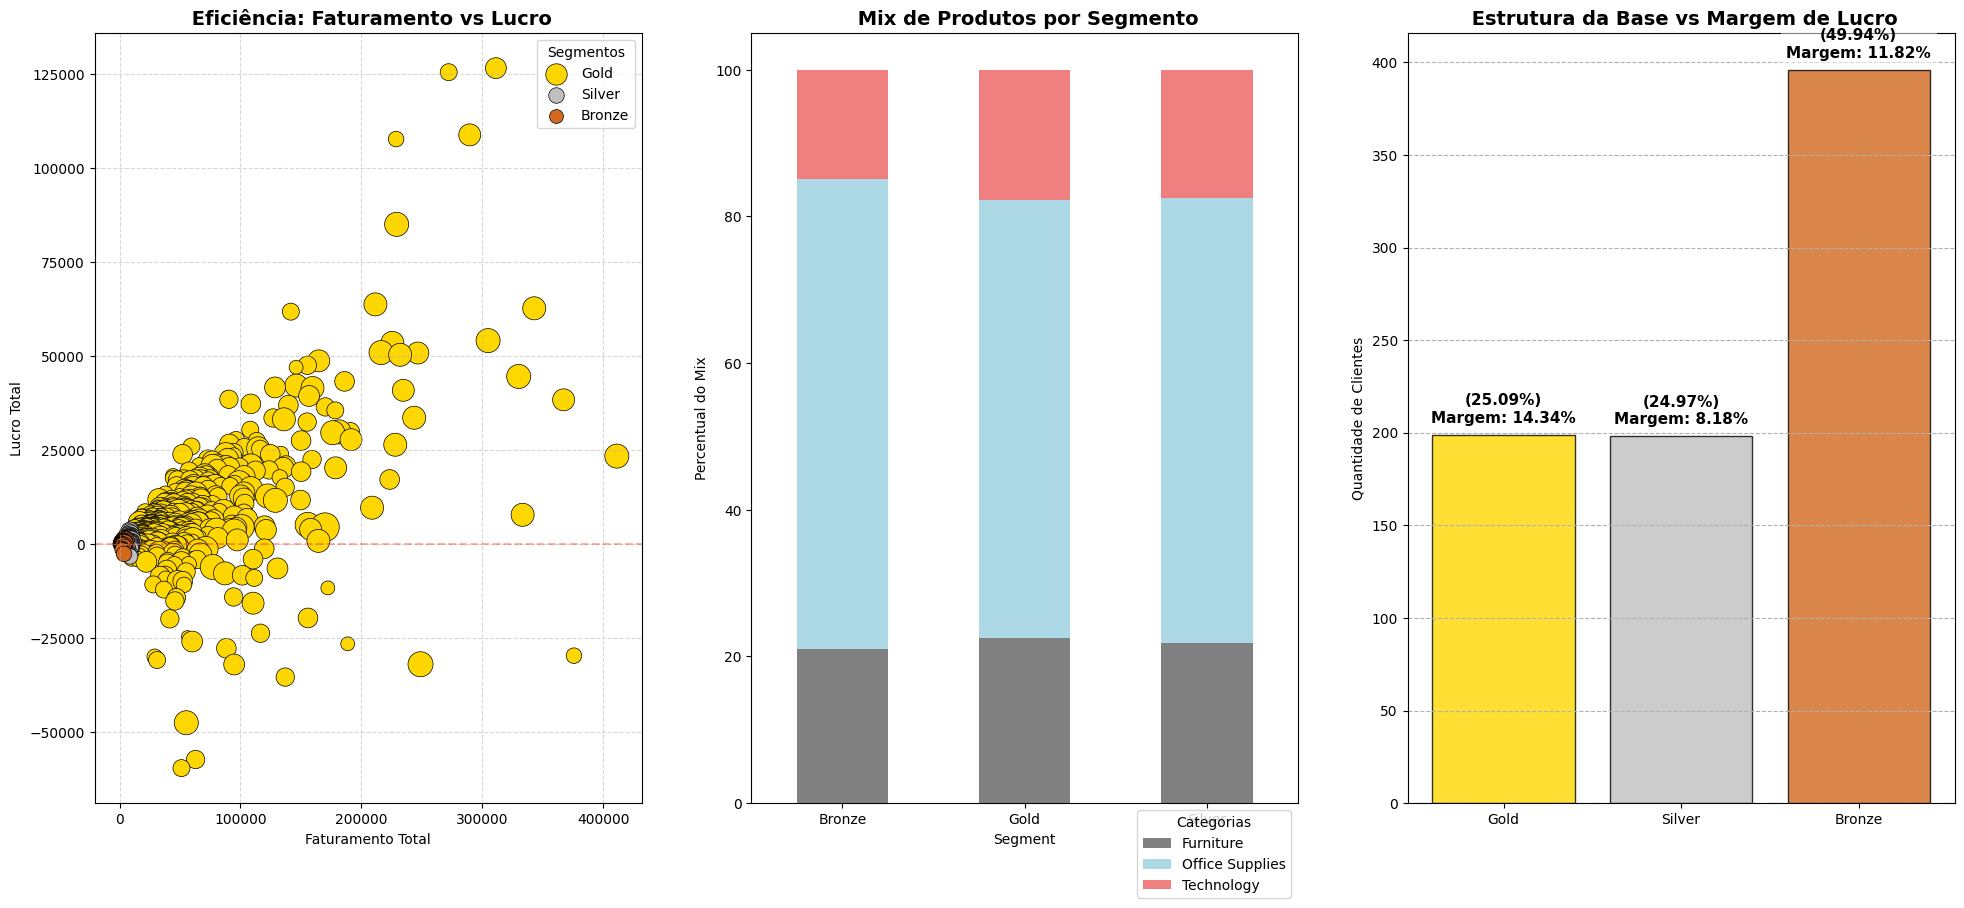

In [116]:
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 10))

# GRÁFICO 1: SCATTER PLOT
cores = {'Gold': 'gold', 'Silver': 'silver', 'Bronze': 'chocolate'}
for segmento, cor in cores.items():
    dados = df_customers[df_customers['Segment'] == segmento]
    ax1.scatter(
        x=dados['Total_Revenue'], y=dados['total_Profit'], 
        c=cor, label=segmento, s=dados['Total_Orders'] * 25, edgecolors='black', linewidths=0.5
    )
ax1.set_title(' Eficiência: Faturamento vs Lucro', fontsize=14, fontweight='bold')
ax1.set_xlabel('Faturamento Total')
ax1.set_ylabel('Lucro Total')
ax1.axhline(0, color='red', linestyle='--', alpha=0.3)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(title='Segmentos')

# GRÁFICO 2: BARRAS EMPILHADAS
df_pivot = df_cat.pivot(index='Segment', columns='Category', values='Qtd_Pedidos')
df_perc = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100
df_perc.plot(kind='bar', stacked=True, ax=ax2, color=['gray', 'lightblue', 'lightcoral'])
ax2.set_title(' Mix de Produtos por Segmento', fontsize=14, fontweight='bold')
ax2.set_ylabel('Percentual do Mix')
ax2.set_xticklabels(df_perc.index, rotation=0)
ax2.legend(title='Categorias', bbox_to_anchor=(1, 0))

# GRÁFICO 3: ESTRUTURA E MARGEM
df_resumo_final = df_pareto.merge(df_financeiro, on='Segment')

bars = ax3.bar(df_resumo_final['Segment'], df_resumo_final['Qtd_Clientes'], 
               color=['gold', 'silver', 'chocolate'], edgecolor='black', alpha=0.8)

plt.title(' Estrutura da Base vs Margem de Lucro', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade de Clientes')
plt.grid(axis='y', linestyle='--')

for i, bar in enumerate(bars):
    height = bar.get_height()
    perc_clientes = df_resumo_final.loc[i, 'Perc_Clientes']
    margem = df_resumo_final.loc[i, 'Margem_Lucro_Perc']
    
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, 
             f'({perc_clientes}%)\nMargem: {margem}%', 
             ha='center', va='bottom', fontsize=11, fontweight='bold', 
             color='black', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.show()

In [ ]:
#INSIGHTS:
'''
O Dado: O Ticket Médio do segmento Gold ($ 14.493) é quase 7x maior que o do Bronze ($ 2.213).
Ação Recomendada: Implementar um atendimento exclusivo para os 199 clientes Gold, garantindo que eles não migrem para a concorrência, já que perdê-los causaria um impacto imediato de 65% no faturamento.
vale também a criação de um programa de fidelidade para os clientes Gold, incentivando-os a sua permanência, consolidando assim a maior fatia da receita total da empresa.'''
#INSIGHT:
'''
O Dado: O volume de vendas em Office Supplies é massivo em todos os grupos.
Criar uma campanha de Upsell direcionada: oferecer itens de tecnologia com desconto progressivo para clientes Bronze/Silver/Gold que possuem alta recorrência em Office Supplies, tentando "subi-los" de categoria e atrair recorrência.'''
#INSIGHT
'''
O Dado: 25% dos clientes (Gold) geram 65% do faturamento e possuem a melhor margem de lucro (14.34%). O grupo Silver, apesar de intermediário, tem a menor margem (8.18%).
Ação Recomendada: Revisar a tabela de preços e descontos para o segmento Silver. O objetivo deve ser aumentar a margem desse grupo para os níveis do Bronze (11%) ou Gold (14%), otimizando o lucro sem necessariamente precisar de novos clientes.'''

SyntaxError: invalid decimal literal (840688267.py, line 2)